# Exploratory Data Analysis

## Health Report for downloaded datasets

In [15]:
import pandas as pd


### CS-IC-2010

#### Basic Inspection from csv file

In [16]:
# Load a sample to avoid OOM (Out of Memory errors)
df = pd.read_csv('../data/raw/csic_2010.csv', nrows=100000)
print("--- Dataset: CS-IC-2010 ---")
print("Columns:", df.columns.tolist())

print("\n--- Rows ---")
print(f"{len(df)}")

print("\n--- Unique Categories ---")
print(df['classification'].unique())

print("\n--- Unique Labels ---")
print(df['Unnamed: 0'].unique())

print("\n--- Distribution (Counts) ---")
print(df.groupby(['classification', 'Unnamed: 0']).size().reset_index(name='count'))

with pd.option_context('display.max_colwidth', None):
    # See 5 random rows to check different attack categories
    result = df.sample(5)
    display(result)

--- Dataset: CS-IC-2010 ---
Columns: ['Unnamed: 0', 'Method', 'User-Agent', 'Pragma', 'Cache-Control', 'Accept', 'Accept-encoding', 'Accept-charset', 'language', 'host', 'cookie', 'content-type', 'connection', 'lenght', 'content', 'classification', 'URL']

--- Rows ---
61065

--- Unique Categories ---
[0 1]

--- Unique Labels ---
['Normal' 'Anomalous']

--- Distribution (Counts) ---
   classification Unnamed: 0  count
0               0     Normal  36000
1               1  Anomalous  25065


,Unnamed: 0,Method,User-Agent,Pragma,Cache-Control,Accept,Accept-encoding,Accept-charset,language,host,cookie,content-type,connection,lenght,content,classification,URL
3449,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko),no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=0.8,image/png,*/*;q=0.5","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=2A26F7D5166AFC3802C265E98644AB82,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/miembros/salir.jsp HTTP/1.1
1769,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko),no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=0.8,image/png,*/*;q=0.5","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=B92BDC5F7922CA1D6EAB60782CC9981F,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/publico/caracteristicas.jsp?id=1 HTTP/1.1
1127,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko),no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=0.8,image/png,*/*;q=0.5","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=0F559CED15DB75E5FFC87900E7E74C23,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/publico/pagar.jsp?modo=insertar&precio=450&B1=Pasar+por+caja HTTP/1.1
55784,Anomalous,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko),no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=0.8,image/png,*/*;q=0.5","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=EA1432054D05D9DACD1FEC7F983EDE4A,NaN,close,NaN,NaN,1,http://localhost:8080/tienda1/publico/autenticar.jsp?modo=entrar&login=schlacht&pwd=43s8a&rememberA=off&B1=Entrar HTTP/1.1
26072,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko),no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=0.8,image/png,*/*;q=0.5","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=C69C136653E3575915F6BFA17C76988C,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/publico/entrar.jsp?errorMsg=Credenciales+incorrectas HTTP/1.1


#### Inspection of parquet file

In [23]:
df = pd.read_parquet("../data/normalized/CSIC 2010.parquet")
print("--- Dataset: CS-IC-2010 ---")
print("Columns:", df.columns.tolist())

print("\n--- Rows ---")
print(f"{len(df)}")

print("\n--- Unique Categories ---")
print(df['attack_class'].unique())

print("\n--- Unique Labels ---")
print(df['label'].unique())

print("\n--- Distribution (Counts) ---")
print(df.groupby(['attack_class', 'label']).size().reset_index(name='count'))

with pd.option_context('display.max_colwidth', None):
    # See 5 random rows to check different attack categories
    result = df.sample(5)
    display(result)

print("\n--- Unique Raw ---")
print(df['raw'].nunique())


--- Dataset: CS-IC-2010 ---
Columns: ['id', 'method', 'path', 'query_string', 'headers', 'body', 'raw', 'label', 'attack_class', 'source', 'split']

--- Rows ---
61065

--- Unique Categories ---
['benign' 'unknown']

--- Unique Labels ---
[0 1]

--- Distribution (Counts) ---
  attack_class  label  count
0       benign      0  36000
1      unknown      1  25065


,id,method,path,query_string,headers,body,raw,label,attack_class,source,split
2664,c7dada3a-a52b-4c38-9558-ddd466017b84,GET,/tienda1/index.jsp HTTP/1.1,,"{""User-Agent"": ""Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko)"", ""Pragma"": ""no-cache"", ""Cache-Control"": ""no-cache"", ""Accept"": ""text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=0.8,image/png,*/*;q=0.5"", ""Accept-Encoding"": ""x-gzip, x-deflate, gzip, deflate"", ""Accept-Charset"": ""utf-8, utf-8;q=0.5, *;q=0.5"", ""Accept-Language"": ""en"", ""Host"": ""localhost:8080"", ""Cookie"": ""JSESSIONID=AC46526236EA009331B6EAD6E85A099B"", ""Connection"": ""close""}",,"GET /tienda1/index.jsp HTTP/1.1 HTTP/1.1\r\nUser-Agent: Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko)\r\nPragma: no-cache\r\nCache-Control: no-cache\r\nAccept: text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=0.8,image/png,*/*;q=0.5\r\nAccept-Encoding: x-gzip, x-deflate, gzip, deflate\r\nAccept-Charset: utf-8, utf-8;q=0.5, *;q=0.5\r\nAccept-Language: en\r\nHost: localhost:8080\r\nCookie: JSESSIONID=AC46526236EA009331B6EAD6E85A099B\r\nConnection: close\r\n",0,benign,CSIC 2010,
17991,e48d2ec5-5b00-4d80-a63d-7479e10f6c5b,POST,/tienda1/miembros/editar.jsp HTTP/1.1,,"{""User-Agent"": ""Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko)"", ""Pragma"": ""no-cache"", ""Cache-Control"": ""no-cache"", ""Accept"": ""text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=0.8,image/png,*/*;q=0.5"", ""Accept-Encoding"": ""x-gzip, x-deflate, gzip, deflate"", ""Accept-Charset"": ""utf-8, utf-8;q=0.5, *;q=0.5"", ""Accept-Language"": ""en"", ""Host"": ""localhost:8080"", ""Cookie"": ""JSESSIONID=3D035AD1FC72D90E541864BD0D2303CB"", ""Content-Type"": ""application/x-www-form-urlencoded"", ""Connection"": ""close"", ""Content-Length"": ""246""}",modo=registro&login=chung&password=reele.cto&nombre=Franklin&apellidos=Iranzo&email=roussel%40santacruzdelvoto.ws&dni=96269598Q&direccion=Calle+Bernat+De+Santa+Eugenia+90+&ciudad=Sariego&cp=17850&provincia=Huesca&ntc=7626699319590675&B1=Registrar,"POST /tienda1/miembros/editar.jsp HTTP/1.1 HTTP/1.1\r\nUser-Agent: Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko)\r\nPragma: no-cache\r\nCache-Control: no-cache\r\nAccept: text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=0.8,image/png,*/*;q=0.5\r\nAccept-Encoding: x-gzip, x-deflate, gzip, deflate\r\nAccept-Charset: utf-8, utf-8;q=0.5, *;q=0.5\r\nAccept-Language: en\r\nHost: localhost:8080\r\nCookie: JSESSIONID=3D035AD1FC72D90E541864BD0D2303CB\r\nContent-Type: application/x-www-form-urlencoded\r\nConnection: close\r\nContent-Length: 246\r\n\r\nmodo=registro&login=chung&password=reele.cto&nombre=Franklin&apellidos=Iranzo&email=roussel%40santacruzdelvoto.ws&dni=96269598Q&direccion=Calle+Bernat+De+Santa+Eugenia+90+&ciudad=Sariego&cp=17850&provincia=Huesca&ntc=7626699319590675&B1=Registrar",0,benign,CSIC 2010,
11656,7ad2161c-7c71-4ab1-9571-1d53c1a787c1,GET,/tienda1/miembros/fotos.jsp HTTP/1.1,,"{""User-Agent"": ""Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko)"", ""Pragma"": ""no-cache"", ""Cache-Control"": ""no-cache"", ""Accept"": ""text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=0.8,image/png,*/*;q=0.5"", ""Accept-Encoding"": ""x-gzip, x-deflate, gzip, deflate"", ""Accept-Charset"": ""utf-8, utf-8;q=0.5, *;q=0.5"", ""Accept-Language"": ""en"", ""Host"": ""localhost:8080"", ""Cookie"": ""JSESSIONID=465E3E49F859C96249CC72B02502F8CD"", ""Connection"": ""close""}",,"GET /tienda1/miembros/fotos.jsp HTTP/1.1 HTTP/1.1\r\nUser-Agent: Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko)\r\nPragma: no-cache\r\nCache-Control: no-cache\r\nAccept: text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=0.8,image/png,*/*;q=0.5\r\nAccept-Encoding: x-gzip, x-deflate, gzip, d


--- Unique Raw ---
61065


### SR-BH 2020

#### Basic Inspection of csv file

In [19]:
!pwd
# Load a sample to avoid OOM (Out of Memory errors)
df = pd.read_csv('../data/raw/sr_bh_2020.csv', nrows=1000000)
print("--- Dataset: SR-BH 2020 ---")
print("Columns:", df.columns.tolist())

print("\n--- Unique Payloads ---")
print(f"{df['text'].nunique()} / {len(df)}")

print("\n--- Unique Categories ---")
print(df['category'].unique())

print("\n--- Unique Labels ---")
print(df['label'].unique())

print("\n--- Distribution (Counts) ---")
print(df.groupby(['category', 'label']).size().reset_index(name='count'))

with pd.option_context('display.max_colwidth', None):
    # See 5 random rows to check different attack categories
    result = df.sample(2)
    display(result)

print("\n--- Row idx=61091 ---")
with pd.option_context('display.max_colwidth', None):
    display(df.loc[[61091]].T)

print("\n--- Row idx=61290 ---")
with pd.option_context('display.max_colwidth', None):
    display(df.loc[[61290]].T)

df[df['text'] == '/blog/index.php/comments/feed/']

/home/ndelessy/Projects/ai-waf-v2/notebooks
--- Dataset: SR-BH 2020 ---
Columns: ['text', 'label', 'category']

--- Unique Payloads ---
539846 / 607312

--- Unique Categories ---
['Normal' 'Manipulation' 'Injection' 'Scanning for Vulnerable Software'
 'Fake the Source of Data' 'HTTP abusion'
 '16 - Dictionary-based Password Attack']

--- Unique Labels ---
['000 - Normal' '126 - Path Traversal' '66 - SQL Injection'
 '272 - Protocol Manipulation' '310 - Scanning for Vulnerable Software'
 '242 - Code Injection' '194 - Fake the Source of Data'
 '34 - HTTP Response Splitting' '274 - HTTP Verb Tampering'
 '88 - OS Command Injection' '153 - Input Data Manipulation'
 '33 - HTTP Request Smuggling']

--- Distribution (Counts) ---
                                 category  \
0   16 - Dictionary-based Password Attack   
1   16 - Dictionary-based Password Attack   
2   16 - Dictionary-based Password Attack   
3   16 - Dictionary-based Password Attack   
4                 Fake the Source of Data   


,text,label,category
591083,"Method: GET Host:/blog/index.php/feed/ Body: Content-Type: Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/30.0.1599.101 Safari/537.36 User-Agent: Referer: Cookie: Accept: */* Accept-language: Accept-Encodinggzip, deflate",000 - Normal,Normal
597444,Method: GET Host:/blog/wp-login.php?action=lostpassword%60sleep+15%60 Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: Referer: comment_author_url_1aefbe2f76edd740f8e362f39da3353b=http%3A%2F%2Fwww.example.com; comment_author_email_1aefbe2f76edd740f8e362f39da3353b=foo-bar%40example.com; comment_author_1aefbe2f76edd740f8e362f39da3353b=growth; wordpress_logged_in_1aefbe2f76edd740f8e362f39da3353b=rafael%7C1595212059%7CGWgAWVHapC2bzAMywZ77DCFlV58k9y04hBeDt9B2wpg%7C59006f949e57d0c4fd439f571f0a913f28f8cabfb99520b35997b552dc918655; wordpress_test_cookie=WP+Cookie+check Cookie: Accept: Accept-language: Accept-Encoding,88 - OS Command Injection,Injection



--- Row idx=61091 ---


,61091
text,Method: GET Host:/blog/index.php/my-account/https%253A%252F%252Fwww.google.com%252F/%7B%7B%20data.icon Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: http://test-site.com/blog/index.php/my-account/edit-profile/%7B%7B%20data.icon%20%7D%7D Referer: wordpress_test_cookie=WP+Cookie+check Cookie: Accept: Accept-language: Accept-Encoding
label,194 - Fake the Source of Data
category,Fake the Source of Data



--- Row idx=61290 ---


,61290
text,Method: GET Host:/blog/HTTP%253A%252F%252Fwww.google.com%253A80%252F/my-account/edit-profile/%7B%7B%20data.image.src%20%7D%7D Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: http://test-site.com/blog/index.php/my-account/edit-profile/ Referer: wordpress_test_cookie=WP+Cookie+check Cookie: Accept: Accept-language: Accept-Encoding
label,194 - Fake the Source of Data
category,Fake the Source of Data


,text,label,category


#### Basic Inspection of parquet file

In [25]:
!pwd
df = pd.read_parquet("../data/normalized/SR-BH 2020.parquet")
print("--- Dataset: SR-BH 2020 ---")
print("Columns:", df.columns.tolist())

print("\n--- Rows ---")
print(f"{len(df)}")

print("\n--- Unique Categories ---")
print(df['attack_class'].unique())

print("\n--- Unique Labels ---")
print(df['label'].unique())

print("\n--- Distribution (Counts) ---")
print(df.groupby(['attack_class', 'label']).size().reset_index(name='count'))

with pd.option_context('display.max_colwidth', None):
    # See 5 random rows to check different attack categories
    result = df.sample(25)
    display(result)

print("\n--- Row idx=61091 ---")
with pd.option_context('display.max_colwidth', None):
    display(df.loc[[61091]].T)

print("\n--- Row idx=61290 ---")
with pd.option_context('display.max_colwidth', None):
    display(df.loc[[61290]].T)



print("\n--- Unique Raws ---")
print(df['raw'].nunique())


/home/ndelessy/Projects/ai-waf-v2/notebooks
--- Dataset: SR-BH 2020 ---
Columns: ['id', 'method', 'path', 'query_string', 'headers', 'body', 'raw', 'label', 'attack_class', 'source', 'split']

--- Rows ---
607312

--- Unique Categories ---
['benign' 'manipulation' 'injection' 'scanning for vulnerable software'
 'fake the source of data' 'http abusion'
 'dictionary-based password attack']

--- Unique Labels ---
[0 1]

--- Distribution (Counts) ---
                       attack_class  label   count
0                            benign      0  226509
1  dictionary-based password attack      1     306
2           fake the source of data      1   55982
3                      http abusion      1   23715
4                         injection      1  270450
5                      manipulation      1   27968
6  scanning for vulnerable software      1    2382


,id,method,path,query_string,headers,body,raw,label,attack_class,source,split
582411,d4ef5a0b-184b-4c86-802c-fd2f052042bb,GET,/blog/wp-login.php,action=register,"{""Content-Type"": ""Mozilla/5.0 (iPhone; CPU iPhone OS 8_0_2 like Mac OS X) AppleWebKit/600.1.4 (KHTML, like Gecko) Version/8.0 Mobile/12A405 Safari/600.1.4"", ""Accept"": ""*/*"", ""Accept-Language"": ""Accept-Encodinggzip, deflate""}",,"GET /blog/wp-login.php?action=register HTTP/1.1\r\nContent-Type: Mozilla/5.0 (iPhone; CPU iPhone OS 8_0_2 like Mac OS X) AppleWebKit/600.1.4 (KHTML, like Gecko) Version/8.0 Mobile/12A405 Safari/600.1.4\r\nAccept: */*\r\nAccept-Language: Accept-Encodinggzip, deflate\r\n",0,benign,SR-BH 2020,
585013,d9b6e7c0-0992-449a-b77d-53aeb7969394,GET,/blog/index.php/comments/feed/,,"{""Content-Type"": ""Mozilla/5.0 (Linux; U; Android 4.0.3; en-us; KFTT Build/IML74K) AppleWebKit/537.36 (KHTML, like Gecko) Silk/3.68 like Chrome/39.0.2171.93 Safari/537.36"", ""Accept"": ""*/*"", ""Accept-Language"": ""Accept-Encodinggzip, deflate""}",,"GET /blog/index.php/comments/feed/ HTTP/1.1\r\nContent-Type: Mozilla/5.0 (Linux; U; Android 4.0.3; en-us; KFTT Build/IML74K) AppleWebKit/537.36 (KHTML, like Gecko) Silk/3.68 like Chrome/39.0.2171.93 Safari/537.36\r\nAccept: */*\r\nAccept-Language: Accept-Encodinggzip, deflate\r\n",0,benign,SR-BH 2020,
480914,cd67e028-4e22-4065-98ea-ff1950f80d11,GET,/blog/index.php/2020%27+AND+5212%3D9148--+-/03/27,,"{""Content-Type"": ""Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0"", ""User-Agent"": ""http://test-site.com/blog/index.php/2020/03/27"", ""Referer"": ""comment_author_url_1aefbe2f76edd740f8e362f39da3353b=http%3A%2F%2Fwww.example.com; comment_author_email_1aefbe2f76edd740f8e362f39da3353b=foo-bar%40example.com; comment_author_1aefbe2f76edd740f8e362f39da3353b=theory; wordpress_test_cookie=WP+Cookie+check"", ""Accept-Language"": ""Accept-Encoding""}",,GET /blog/index.php/2020%27+AND+5212%3D9148--+-/03/27 HTTP/1.1\r\nContent-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0\r\nUser-Agent: http://test-site.com/blog/index.php/2020/03/27\r\nReferer: comment_author_url_1aefbe2f76edd740f8e362f39da3353b=http%3A%2F%2Fwww.example.com; comment_author_email_1aefbe2f76edd740f8e362f39da3353b=foo-bar%40example.com; comment_author_1aefbe2f76edd740f8e362f39da3353b=theory; wordpress_test_cookie=WP+Cookie+check\r\nAccept-Language: Accept-Encoding\r\n,1,injection,SR-BH 2020,
120739,799d931d-f3e9-4c05-89c1-1876e2016500,GET,/blog+OR+1%3D1+--+/index.php/2020/04,,"{""Content-Type"": ""Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0"", ""User-Agent"": ""http://test-site.com/"", ""Referer"": ""wordpress_logged_in_1aefbe2f76edd740f8e362f39da3353b=rafael%7C1595186814%7CJXKR2dCAupLoAglXHclubbgwQJ4BL3zNKjxcob6dgUn%7Cfd5bc3380dc730cacaf855e46730c46b2fa753b2bb8d9f1096c95b5b8090acb3"", ""Accept-Language"": ""Accept-Encoding""}",,GET /blog+OR+1%3D1+--+/index.php/2020/04 HTTP/1.1\r\nContent-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0\r\nUser-Agent: http://test-site.com/\r\nReferer: wordpress_logged_in_1aefbe2f76edd740f8e362f39da3353b=rafael%7C1595186814%7CJXKR2dCAupLoAglXHclubbgwQJ4BL3zNKjxcob6dgUn%7Cfd5bc3380dc730cacaf855e46730c46b2fa753b2bb8d9f1096c95b5b8090acb3\r\nAccept-Language: Accept-Encoding\r\n,1,injection,SR-BH 2020,
111974,fd7f4225-0468-426f-a3cd-a661efc271f3,GET,/blog/index.php/2020/03/zApPX94sS/qui-ratione-maxime-dolores-consequatur,,"{""Content-Type"": ""Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0"", ""Referer"": ""wordpress_test_cookie=WP+Cookie+check"", ""Accept-Language"": ""Accept-Encoding""}",,GET /blog/index.php/2020/03/zApPX94sS/qui-ratione-maxime-dolores-consequatur HTTP/1.1\r\nContent-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0\r\nReferer: wordpress_test_cookie=WP+Cookie+check\r\nAccept-Language: Accept-Encoding\r\n,0,benign,SR-BH 2020,
141012,3ae09a89-d7dd-4c49-81d1-ab40c00afdca,GE


--- Row idx=61091 ---


,61091
id,3a882729-cde5-4b23-847c-9562472f95b8
method,GET
path,/blog/index.php/my-account/https%253A%252F%252Fwww.google.com%252F/%7B%7B%20data.icon
query_string,
headers,"{""Content-Type"": ""Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0"", ""User-Agent"": ""http://test-site.com/blog/index.php/my-account/edit-profile/%7B%7B%20data.icon%20%7D%7D"", ""Referer"": ""wordpress_test_cookie=WP+Cookie+check"", ""Accept-Language"": ""Accept-Encoding""}"
body,
raw,GET /blog/index.php/my-account/https%253A%252F%252Fwww.google.com%252F/%7B%7B%20data.icon HTTP/1.1\r\nContent-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0\r\nUser-Agent: http://test-site.com/blog/index.php/my-account/edit-profile/%7B%7B%20data.icon%20%7D%7D\r\nReferer: wordpress_test_cookie=WP+Cookie+check\r\nAccept-Language: Accept-Encoding\r\n
label,1
attack_class,fake the source of data
source,SR-BH 2020



--- Row idx=61290 ---


,61290
id,94842159-5483-49ba-abed-297ebf1f19a7
method,GET
path,/blog/HTTP%253A%252F%252Fwww.google.com%253A80%252F/my-account/edit-profile/%7B%7B%20data.image.src%20%7D%7D
query_string,
headers,"{""Content-Type"": ""Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0"", ""User-Agent"": ""http://test-site.com/blog/index.php/my-account/edit-profile/"", ""Referer"": ""wordpress_test_cookie=WP+Cookie+check"", ""Accept-Language"": ""Accept-Encoding""}"
body,
raw,GET /blog/HTTP%253A%252F%252Fwww.google.com%253A80%252F/my-account/edit-profile/%7B%7B%20data.image.src%20%7D%7D HTTP/1.1\r\nContent-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0\r\nUser-Agent: http://test-site.com/blog/index.php/my-account/edit-profile/\r\nReferer: wordpress_test_cookie=WP+Cookie+check\r\nAccept-Language: Accept-Encoding\r\n
label,1
attack_class,fake the source of data
source,SR-BH 2020



--- Unique Raws ---
532222


In [13]:
with pd.option_context('display.max_colwidth', None):
    # See 5 random rows to check different attack categories
    result = df.sample(5)
    display(result)

,text,label,category,url,method,body
365,"Method: GET Host:/blog/index.php/comments/feed/ Body: Content-Type: Mozilla/5.0 (Macintosh; Intel Mac OS X 10.9; rv:33.0) Gecko/20100101 Firefox/33.0 User-Agent: Referer: Cookie: Accept: */* Accept-language: Accept-Encodinggzip, deflate",000 - Normal,Normal,/,GET,NaN
8613,Method: GET Host:/blog/index.php/..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F/03/27/qui-ratione-maxime-dolores-consequatur Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: http://test-site.com/blog/index.php/2020/03/27/qui-ratione-maxime-dolores-consequatur/ Referer: wordpress_test_cookie=WP+Cookie+check Cookie: Accept: Accept-language: Accept-Encoding,126 - Path Traversal,Manipulation,/,GET,NaN
8274,Method: GET Host:/blog/index.php/2020/c%3A%2F/23/fuga-aut-recusandae-sed-dolor-quia/feed Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: Referer: wordpress_test_cookie=WP+Cookie+check Cookie: Accept: Accept-language: Accept-Encoding,000 - Normal,Normal,/,GET,NaN
2242,"Method: GET Host:/blog/index.php/comments/feed/ Body: Content-Type: Mozilla/5.0 (iPad; CPU OS 7_1_2 like Mac OS X) AppleWebKit/537.51.2 (KHTML, like Gecko) Mobile/11D257 User-Agent: Referer: Cookie: Accept: */* Accept-language: Accept-Encodinggzip, deflate",000 - Normal,Normal,/,GET,NaN
3456,Method: GET Host:/blog/index.php/vitae-dolores-quidem-possimus-aut-voluptatibus/feed/.git/index Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: Referer: wordpress_test_cookie=WP+Cookie+check Cookie: Accept: Accept-language: Accept-Encoding,126 - Path Traversal,Manipulation,/,GET,NaN


#### Targeted Inpection

In [14]:
with pd.option_context('display.max_colwidth', None):
    # Show 5 rows where the label is Normal
    result = df[df['label'] == '000 - Normal'].head(5)
    display(result)

,text,label,category,url,method,body
0,"Method: GET Host:/blog/index.php/2020/04/04/voluptatum-reprehenderit-maiores-ab-sequi-quaerat/ Body: Content-Type: Mozilla/5.0 (Macintosh; Intel Mac OS X 10.6; rv:36.0) Gecko/20100101 Firefox/36.0 User-Agent: Referer: Cookie: Accept: */* Accept-language: Accept-Encodinggzip, deflate",000 - Normal,Normal,/,GET,NaN
1,"Method: GET Host:/blog/xmlrpc.php?rsd Body: Content-Type: Mozilla/4.0 (compatible; MSIE 6.0; Windows NT 5.1; WOW64; Trident/4.0; SLCC2; .NET CLR 2.0.50727; .NET CLR 3.5.30729; .NET CLR 3.0.30729; .NET4.0C; .NET4.0E) User-Agent: Referer: Cookie: Accept: */* Accept-language: Accept-Encodinggzip, deflate",000 - Normal,Normal,/,GET,NaN
2,"Method: GET Host:/blog/index.php/2020/04/04/nihil-tenetur-et-ad-in-dolores/ Body: Content-Type: Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_2) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/44.0.2403.125 Safari/537.36 User-Agent: Referer: Cookie: Accept: */* Accept-language: Accept-Encodinggzip, deflate",000 - Normal,Normal,/,GET,NaN
3,"Method: GET Host:/blog/index.php/2020/04/04/explicabo-qui-fuga-distinctio-dolores-voluptatibus-sit/ Body: Content-Type: Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/46.0.2490.22 Safari/537.36 User-Agent: Referer: Cookie: Accept: */* Accept-language: Accept-Encodinggzip, deflate",000 - Normal,Normal,/,GET,NaN
4,"Method: GET Host:/blog/index.php/2020/04/04/explicabo-qui-fuga-distinctio-dolores-voluptatibus-sit/ Body: Content-Type: Mozilla/5.0 (Windows NT 5.1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/43.0.2357.134 Safari/537.36 User-Agent: Referer: Cookie: Accept: */* Accept-language: Accept-Encodinggzip, deflate",000 - Normal,Normal,/,GET,NaN


In [15]:
with pd.option_context('display.max_colwidth', None):
    # Show 5 rows where the label is Normal
    result = df[df['label'] == '126 - Path Traversal'].head(5)
    display(result)

,text,label,category,url,method,body
2400,Method: GET Host:/.svn/entries Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: Referer: Cookie: Accept: Accept-language: Accept-Encoding,126 - Path Traversal,Manipulation,/,GET,NaN
2401,Method: GET Host:/.git/index Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: Referer: Cookie: Accept: Accept-language: Accept-Encoding,126 - Path Traversal,Manipulation,/,GET,NaN
2404,Method: GET Host:/blog/.svn/entries Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: Referer: wordpress_logged_in_1aefbe2f76edd740f8e362f39da3353b=rafael%7C1595179514%7C1ldatsgnw2jqMXxJ0LW4HRJoq4C1kZ8VHXV2nlPAKTJ%7C3953326980c143f4ab8dc38e3f9f4d9d8d49fec328cb23e6bd9818490adde67e Cookie: Accept: Accept-language: Accept-Encoding,126 - Path Traversal,Manipulation,/,GET,NaN
2405,Method: GET Host:/blog/.git/index Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: Referer: wordpress_logged_in_1aefbe2f76edd740f8e362f39da3353b=rafael%7C1595179514%7C1ldatsgnw2jqMXxJ0LW4HRJoq4C1kZ8VHXV2nlPAKTJ%7C3953326980c143f4ab8dc38e3f9f4d9d8d49fec328cb23e6bd9818490adde67e Cookie: Accept: Accept-language: Accept-Encoding,126 - Path Traversal,Manipulation,/,GET,NaN
2406,Method: GET Host:/blog/index.php/my-account/.svn/entries Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: Referer: wordpress_logged_in_1aefbe2f76edd740f8e362f39da3353b=rafael%7C1595179514%7C1ldatsgnw2jqMXxJ0LW4HRJoq4C1kZ8VHXV2nlPAKTJ%7C3953326980c143f4ab8dc38e3f9f4d9d8d49fec328cb23e6bd9818490adde67e Cookie: Accept: Accept-language: Accept-Encoding,126 - Path Traversal,Manipulation,/,GET,NaN


#### Check Label and Category Ratios

This identifies if your dataset is imbalanced. In WAF research, an **extreme imbalance** (e.g., 99% benign) requires specific handling during training.

In [16]:

# 1. Binary Label Distribution (0 vs 1)
print("--- Binary Label Counts ---")
print(df['label'].value_counts())
print("\n--- Binary Label Ratios ---")
print(df['label'].value_counts(normalize=True))

# 2. Specific Attack Category Distribution
print("\n--- Attack Category Counts ---")
print(df['category'].value_counts())
print("\n--- Attack Category Ratios ---")
print(df['category'].value_counts(normalize=True))


--- Binary Label Counts ---
label
000 - Normal                              5796
310 - Scanning for Vulnerable Software    2382
126 - Path Traversal                      1806
272 - Protocol Manipulation                 10
66 - SQL Injection                           5
242 - Code Injection                         1
Name: count, dtype: int64

--- Binary Label Ratios ---
label
000 - Normal                              0.5796
310 - Scanning for Vulnerable Software    0.2382
126 - Path Traversal                      0.1806
272 - Protocol Manipulation               0.0010
66 - SQL Injection                        0.0005
242 - Code Injection                      0.0001
Name: proportion, dtype: float64

--- Attack Category Counts ---
category
Normal                              5796
Scanning for Vulnerable Software    2382
Manipulation                        1816
Injection                              6
Name: count, dtype: int64

--- Attack Category Ratios ---
category
Normal                  

#### Cross-Tabulate Label vs. Category

It is a good practice to verify that the label (0 or 1) correctly aligns with the category. This ensures that all categories labeled as "Normal" are actually 0.

In [17]:
# Create a cross-tabulation table
ctab = pd.crosstab(df['category'], df['label'])
print("--- Label Alignment Check ---")
print(ctab)

--- Label Alignment Check ---
label                             000 - Normal  126 - Path Traversal  \
category                                                               
Injection                                    0                     0   
Manipulation                                 0                  1806   
Normal                                    5796                     0   
Scanning for Vulnerable Software             0                     0   

label                             242 - Code Injection  \
category                                                 
Injection                                            1   
Manipulation                                         0   
Normal                                               0   
Scanning for Vulnerable Software                     0   

label                             272 - Protocol Manipulation  \
category                                                        
Injection                                                 

#### Visualizing with a Bar Chart

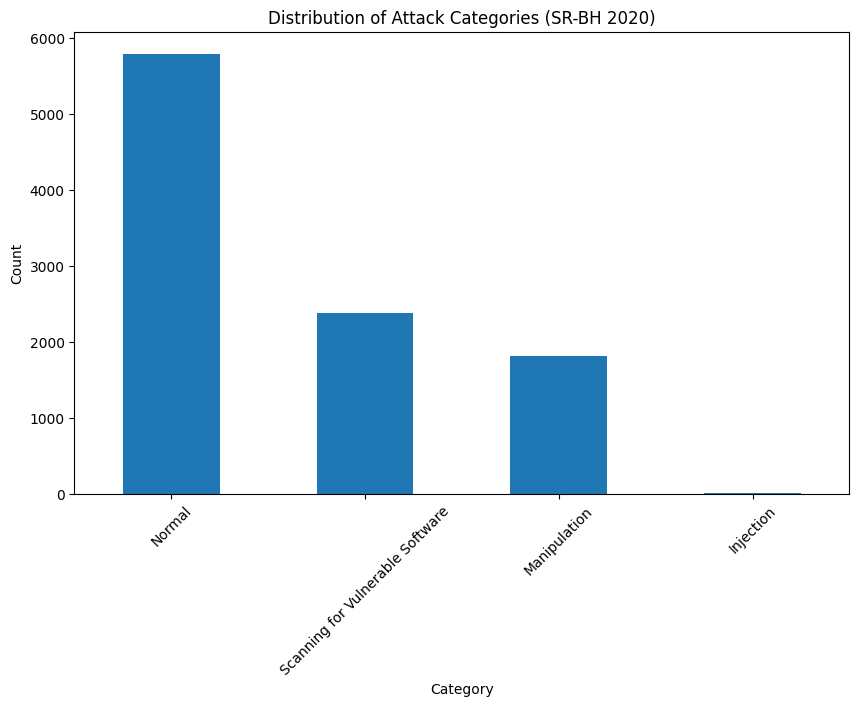

In [18]:
import matplotlib.pyplot as plt

# Plotting the categories
plt.figure(figsize=(10, 6))
df['category'].value_counts().plot(kind='bar')
plt.title('Distribution of Attack Categories (SR-BH 2020)')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

#### Payload Length Analysis

Since we are using DeBERTa-v3, the length of the text field matters. If payloads are extremely long, they will be truncated, potentially losing the malicious part of the string.

In [19]:
# Add a length column for analysis
df['payload_len'] = df['text'].str.len()

print("--- Payload Length Statistics ---")
print(df.groupby('category')['payload_len'].describe())

# Check for empty payloads
print(f"\nEmpty payloads: {df['text'].isna().sum()}")

--- Payload Length Statistics ---
                                   count        mean        std    min    25%  \
category                                                                        
Injection                            6.0  352.666667  32.922130  317.0  326.0   
Manipulation                      1816.0  356.104626  73.016841  193.0  306.0   
Normal                            5796.0  318.537440  75.861232  187.0  269.0   
Scanning for Vulnerable Software  2382.0  209.849706  11.181151  196.0  202.0   

                                    50%     75%    max  
category                                                
Injection                         354.0  367.00  403.0  
Manipulation                      360.0  377.25  623.0  
Normal                            294.0  346.00  723.0  
Scanning for Vulnerable Software  206.0  216.00  284.0  

Empty payloads: 0


#### Merged Parquet

In [26]:
!pwd
df = pd.read_parquet("../data/normalized/all_datasets.parquet")
print("--- Dataset: Combined---")
print("Columns:", df.columns.tolist())

print("\n--- Rows ---")
print(f"{len(df)}")

print("\n--- Unique Categories ---")
print(df['attack_class'].unique())

print("\n--- Unique Labels ---")
print(df['label'].unique())

print("\n--- Distribution (Counts) ---")
print(df.groupby(['attack_class', 'label']).size().reset_index(name='count'))

with pd.option_context('display.max_colwidth', None):
    # See 5 random rows to check different attack categories
    result = df.sample(45)
    display(result)

print("\n--- Unique Raws ---")
print(df['raw'].nunique())

/home/ndelessy/Projects/ai-waf-v2/notebooks
--- Dataset: Combined---
Columns: ['id', 'method', 'path', 'query_string', 'headers', 'body', 'raw', 'label', 'attack_class', 'source', 'split']

--- Rows ---
668377

--- Unique Categories ---
['benign' 'unknown' 'manipulation' 'injection'
 'scanning for vulnerable software' 'fake the source of data'
 'http abusion' 'dictionary-based password attack']

--- Unique Labels ---
[0 1]

--- Distribution (Counts) ---
                       attack_class  label   count
0                            benign      0  262509
1  dictionary-based password attack      1     306
2           fake the source of data      1   55982
3                      http abusion      1   23715
4                         injection      1  270450
5                      manipulation      1   27968
6  scanning for vulnerable software      1    2382
7                           unknown      1   25065


,id,method,path,query_string,headers,body,raw,label,attack_class,source,split
641047,7a5aa6bd-5bd1-466e-8cee-69ef59b9e07b,GET,/blog/index.php/feed/,,"{""Content-Type"": ""Mozilla/5.0 (Windows NT 6.3; WOW64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/44.0.2403.125 Safari/537.36"", ""Accept"": ""*/*"", ""Accept-Language"": ""Accept-Encodinggzip, deflate""}",,"GET /blog/index.php/feed/ HTTP/1.1\r\nContent-Type: Mozilla/5.0 (Windows NT 6.3; WOW64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/44.0.2403.125 Safari/537.36\r\nAccept: */*\r\nAccept-Language: Accept-Encodinggzip, deflate\r\n",0,benign,SR-BH 2020,
331709,a5f37f34-13e7-4047-8b7e-0203dc4ffded,GET,/blog/wp-content/themes/twentyseventeen/assets/js%22%3Bsleep+15%3B%22/html5.js,ver=3.7.3,"{""Content-Type"": ""Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0"", ""User-Agent"": ""http://test-site.com/"", ""Referer"": ""comment_author_url_1aefbe2f76edd740f8e362f39da3353b=http%3A%2F%2Fwww.example.com; comment_author_email_1aefbe2f76edd740f8e362f39da3353b=foo-bar%40example.com; comment_author_1aefbe2f76edd740f8e362f39da3353b=attention; wordpress_test_cookie=WP+Cookie+check; wordpress_logged_in_1aefbe2f76edd740f8e362f39da3353b=rafael%7C1595212059%7CGWgAWVHapC2bzAMywZ77DCFlV58k9y04hBeDt9B2wpg%7C59006f949e57d0c4fd439f571f0a913f28f8cabfb99520b35997b552dc918655"", ""Accept-Language"": ""Accept-Encoding""}",,GET /blog/wp-content/themes/twentyseventeen/assets/js%22%3Bsleep+15%3B%22/html5.js?ver=3.7.3 HTTP/1.1\r\nContent-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0\r\nUser-Agent: http://test-site.com/\r\nReferer: comment_author_url_1aefbe2f76edd740f8e362f39da3353b=http%3A%2F%2Fwww.example.com; comment_author_email_1aefbe2f76edd740f8e362f39da3353b=foo-bar%40example.com; comment_author_1aefbe2f76edd740f8e362f39da3353b=attention; wordpress_test_cookie=WP+Cookie+check; wordpress_logged_in_1aefbe2f76edd740f8e362f39da3353b=rafael%7C1595212059%7CGWgAWVHapC2bzAMywZ77DCFlV58k9y04hBeDt9B2wpg%7C59006f949e57d0c4fd439f571f0a913f28f8cabfb99520b35997b552dc918655\r\nAccept-Language: Accept-Encoding\r\n,1,injection,SR-BH 2020,
354496,29e208fd-4b7d-4fd3-ad3d-ea6de3929685,GET,/blog/index.php/HtTp%3A%2F%2F8501779237819759495.owasp.org/04/04/tempore-odit-cupiditate-voluptas-laudantium-et-facilis,,"{""Content-Type"": ""Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0"", ""User-Agent"": ""http://test-site.com/blog/index.php/2020/04/04/tempore-odit-cupiditate-voluptas-laudantium-et-facilis/"", ""Referer"": ""comment_author_url_1aefbe2f76edd740f8e362f39da3353b=http%3A%2F%2Fwww.example.com; comment_author_email_1aefbe2f76edd740f8e362f39da3353b=foo-bar%40example.com; comment_author_1aefbe2f76edd740f8e362f39da3353b=statement; wordpress_logged_in_1aefbe2f76edd740f8e362f39da3353b=rafael%7C1595217508%7CReeW2M4qh11ya14wgRN2LQggtbLbCpq9uVX846gSuT9%7C9d6b49ff2bbb5593cdaf58b42e9391a5263c4d48dedbaecc1824bff9156cbeab; wordpress_test_cookie=WP+Cookie+check"", ""Accept-Language"": ""Accept-Encoding""}",,GET /blog/index.php/HtTp%3A%2F%2F8501779237819759495.owasp.org/04/04/tempore-odit-cupiditate-voluptas-laudantium-et-facilis HTTP/1.1\r\nContent-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0\r\nUser-Agent: http://test-site.com/blog/index.php/2020/04/04/tempore-odit-cupiditate-voluptas-laudantium-et-facilis/\r\nReferer: comment_author_url_1aefbe2f76edd740f8e362f39da3353b=http%3A%2F%2Fwww.example.com; comment_author_email_1aefbe2f76edd740f8e362f39da3353b=foo-bar%40example.com; comment_author_1aefbe2f76edd740f8e362f39da3353b=statement; wordpress_logged_in_1aefbe2f76edd740f8e362f39da3353b=rafael%7C1595217508%7CReeW2M4qh11ya14wgRN2LQggtbLbCpq9uVX846gSuT9%7C9d6b49ff2bbb5593cdaf58b42e9391a5263c4d48dedbaecc1824bff9156cbeab; wordpress_test_cookie=WP+Cookie+check\r\nAccept-Language: Accept-Encoding\r\n,0,benign,SR-BH 2020,
496003,161b68cd-44d4-4f35-8dda-650e79eb86a4,GET,/blog/index.php/2020/03/23+UNION+ALL+SELECT+NULL%2CNULL%2CNULL%2CNULL


--- Unique Raws ---
593287
